Using device: cuda
Final data directory: /content/dataset/Brain_Cancer


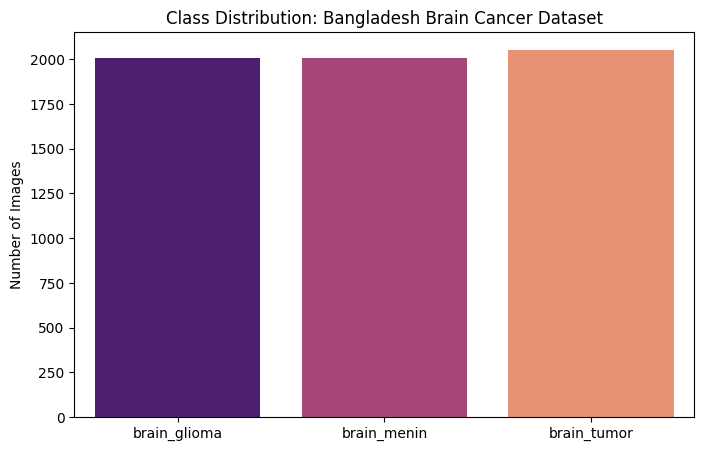

Total Images: 6056
Classes found: ['brain_glioma', 'brain_menin', 'brain_tumor']


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import torchvision
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# check shapes and counts
base_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


# Unzip the file
!unzip -q "/content/Brain_Cancer raw MRI data.zip" -d "/content/dataset"

import os
extracted_path = '/content/dataset'
subfolders = [f for f in os.listdir(extracted_path) if os.path.isdir(os.path.join(extracted_path, f))]

# If the zip put everything inside a single subfolder, we jump into it
if len(subfolders) == 1:
    data_dir = os.path.join(extracted_path, subfolders[0])
else:
    data_dir = extracted_path

print(f"Final data directory: {data_dir}")

raw_dataset = datasets.ImageFolder(data_dir, transform=base_transform)

NUM_CLASSES = len(raw_dataset.classes) # or simply 3 SINCE it's 3 classes

#CLASS DISTRIBUTION
counts = Counter(raw_dataset.targets)
class_names = raw_dataset.classes
counts_dict = {class_names[i]: counts[i] for i in counts}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(counts_dict.keys()), y=list(counts_dict.values()), palette='magma')
plt.title('Class Distribution: Bangladesh Brain Cancer Dataset')
plt.ylabel('Number of Images')
plt.show()

print(f"Total Images: {len(raw_dataset)}")
print(f"Classes found: {class_names}")

In [ ]:
no# Augmentation & Normalization
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Stratified Train/Test Split (70/30)
train_idx, test_idx = train_test_split(
    list(range(len(raw_dataset))),
    test_size=0.3,
    stratify=raw_dataset.targets,
    random_state=42
)

train_set = Subset(datasets.ImageFolder(data_dir, transform=train_transform), train_idx)
test_set = Subset(datasets.ImageFolder(data_dir, transform=test_transform), test_idx)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

print(f"Training samples: {len(train_set)}")
print(f"Test samples: {len(test_set)}")
print(f"Total samples: {len(train_set + test_set)}")

Training samples: 4239
Test samples: 1817
Total samples: 6056



Sample Test Images (Unaugmented):


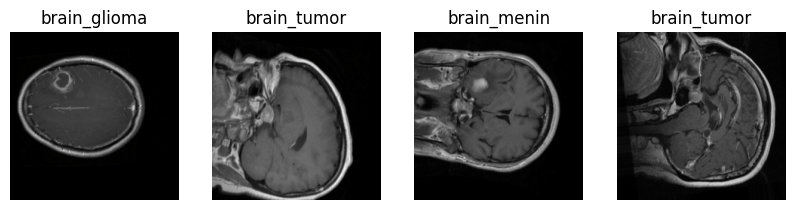

In [ ]:
# VISUALIZE TEST SAMPLES
def imshow(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean # Unnormalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

print("\nSample Test Images (Unaugmented):")
images, labels = next(iter(test_loader))
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    imshow(images[i])
    plt.title(class_names[labels[i]])
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, loader, device, model_name):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Calculate Metrics
    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

    print(f"\n--- {model_name} Final Results ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Precision": precision, "Recall": recall, "F1": f1, "AUC": auc}

**EfficientNet-B0**

EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s]


Epoch 1/15 | Loss: 0.3505 | Test Acc: 0.9703
Epoch 2/15 | Loss: 0.1056 | Test Acc: 0.9840
Epoch 3/15 | Loss: 0.0643 | Test Acc: 0.9862
Epoch 4/15 | Loss: 0.0462 | Test Acc: 0.9912
Epoch 5/15 | Loss: 0.0252 | Test Acc: 0.9950
Epoch 6/15 | Loss: 0.0210 | Test Acc: 0.9983
Epoch 7/15 | Loss: 0.0159 | Test Acc: 0.9967
Epoch 8/15 | Loss: 0.0126 | Test Acc: 0.9978
Epoch 9/15 | Loss: 0.0191 | Test Acc: 0.9956
Epoch 10/15 | Loss: 0.0164 | Test Acc: 0.9989
Epoch 11/15 | Loss: 0.0117 | Test Acc: 0.9989
Epoch 12/15 | Loss: 0.0126 | Test Acc: 0.9956
Epoch 13/15 | Loss: 0.0125 | Test Acc: 0.9989
Epoch 14/15 | Loss: 0.0075 | Test Acc: 0.9989
Epoch 15/15 | Loss: 0.0069 | Test Acc: 0.9994


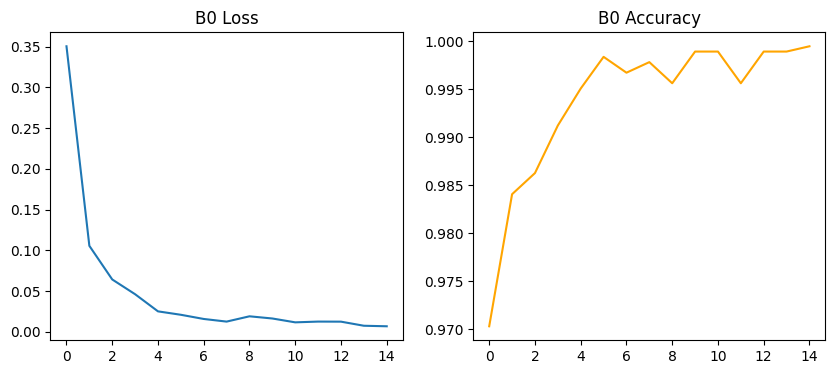


--- EfficientNet-B0 Final Results ---
Accuracy:  0.9994
Precision: 0.9994
Recall:    0.9994
F1-Score:  0.9994
AUC Score: 1.0000


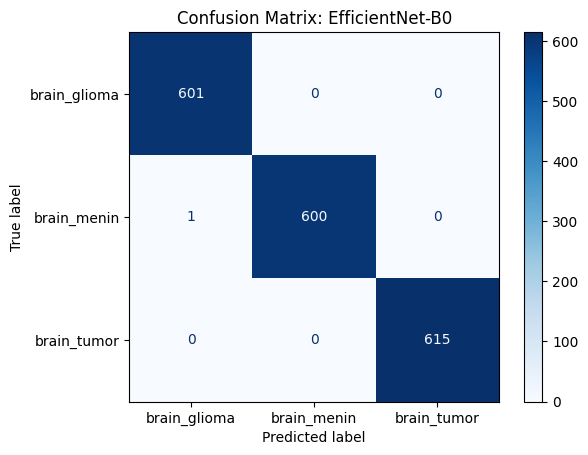

In [ ]:
print("EfficientNet-B0")
model_b0 = models.efficientnet_b0(weights='IMAGENET1K_V1')
model_b0.classifier[1] = nn.Linear(model_b0.classifier[1].in_features, NUM_CLASSES)
model_b0 = model_b0.to(device)

optimizer = optim.Adam(model_b0.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 15
history_b0 = {'train_loss': [], 'test_acc': []}
best_acc_b0 = 0.0

for epoch in range(epochs):
    model_b0.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model_b0(imgs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model_b0.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_b0(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_set)
    history_b0['train_loss'].append(train_loss/len(train_loader))
    history_b0['test_acc'].append(acc)

    if acc > best_acc_b0:
        best_acc_b0 = acc
        torch.save(model_b0.state_dict(), 'efficientnet_b0_best.pth')

    print(f"Epoch {epoch+1}/{epochs} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

# Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_b0['train_loss']); plt.title('B0 Loss')
plt.subplot(1, 2, 2); plt.plot(history_b0['test_acc'], color='orange'); plt.title('B0 Accuracy')
plt.show()

# Load best before evaluation
model_b0.load_state_dict(torch.load('efficientnet_b0_best.pth'))
b0_results = evaluate_model(model_b0, test_loader, device, "EfficientNet-B0")
del model_b0, optimizer; torch.cuda.empty_cache()

**DenseNet169**

DenseNet169
Downloading: "https://download.pytorch.org/models/densenet169-b2777c0a.pth" to /root/.cache/torch/hub/checkpoints/densenet169-b2777c0a.pth


100%|██████████| 54.7M/54.7M [00:00<00:00, 172MB/s]


Epoch 1 | Loss: 0.2412 | Test Acc: 0.9807
Epoch 2 | Loss: 0.0588 | Test Acc: 0.9895
Epoch 3 | Loss: 0.0464 | Test Acc: 0.9835
Epoch 4 | Loss: 0.0180 | Test Acc: 0.9961
Epoch 5 | Loss: 0.0201 | Test Acc: 0.9956
Epoch 6 | Loss: 0.0112 | Test Acc: 0.9846
Epoch 7 | Loss: 0.0226 | Test Acc: 0.9912
Epoch 8 | Loss: 0.0062 | Test Acc: 0.9989
Epoch 9 | Loss: 0.0063 | Test Acc: 0.9928
Epoch 10 | Loss: 0.0095 | Test Acc: 0.9972
Epoch 11 | Loss: 0.0068 | Test Acc: 0.9961
Epoch 12 | Loss: 0.0066 | Test Acc: 0.9989
Epoch 13 | Loss: 0.0043 | Test Acc: 0.9983
Epoch 14 | Loss: 0.0083 | Test Acc: 0.9967
Epoch 15 | Loss: 0.0091 | Test Acc: 0.9967


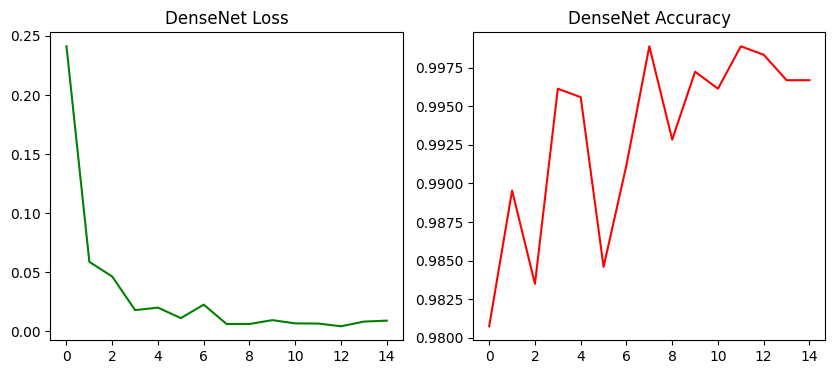


--- DenseNet169 Final Results ---
Accuracy:  0.9989
Precision: 0.9989
Recall:    0.9989
F1-Score:  0.9989
AUC Score: 1.0000


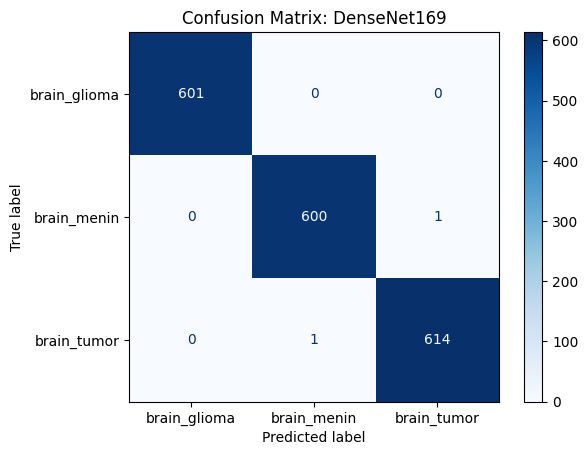

In [ ]:
print("DenseNet169")
model_dense = models.densenet169(weights='IMAGENET1K_V1')
model_dense.classifier = nn.Linear(model_dense.classifier.in_features, NUM_CLASSES)
model_dense = model_dense.to(device)

optimizer = optim.Adam(model_dense.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

history_dense = {'train_loss': [], 'test_acc': []}
best_acc_dense = 0.0

for epoch in range(15):
    model_dense.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_dense(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model_dense.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_dense(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_set)
    history_dense['train_loss'].append(train_loss/len(train_loader))
    history_dense['test_acc'].append(acc)

    if acc > best_acc_dense:
        best_acc_dense = acc
        torch.save(model_dense.state_dict(), 'densenet169_best.pth')

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_dense['train_loss'], color='green'); plt.title('DenseNet Loss')
plt.subplot(1, 2, 2); plt.plot(history_dense['test_acc'], color='red'); plt.title('DenseNet Accuracy')
plt.show()

model_dense.load_state_dict(torch.load('densenet169_best.pth'))
dense_results = evaluate_model(model_dense, test_loader, device, "DenseNet169")
del model_dense, optimizer; torch.cuda.empty_cache()

**ResNet-50**

ResNet-50
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 108MB/s]


Epoch 1 | Loss: 0.1930 | Test Acc: 0.9714
Epoch 2 | Loss: 0.0650 | Test Acc: 0.9741
Epoch 3 | Loss: 0.0451 | Test Acc: 0.9901
Epoch 4 | Loss: 0.0465 | Test Acc: 0.9730
Epoch 5 | Loss: 0.0327 | Test Acc: 0.9950
Epoch 6 | Loss: 0.0206 | Test Acc: 0.9945
Epoch 7 | Loss: 0.0182 | Test Acc: 0.9950
Epoch 8 | Loss: 0.0147 | Test Acc: 0.9956
Epoch 9 | Loss: 0.0063 | Test Acc: 0.9939
Epoch 10 | Loss: 0.0212 | Test Acc: 0.9972
Epoch 11 | Loss: 0.0075 | Test Acc: 0.9879
Epoch 12 | Loss: 0.0143 | Test Acc: 0.9901
Epoch 13 | Loss: 0.0194 | Test Acc: 0.9961
Epoch 14 | Loss: 0.0059 | Test Acc: 0.9978
Epoch 15 | Loss: 0.0088 | Test Acc: 0.9939


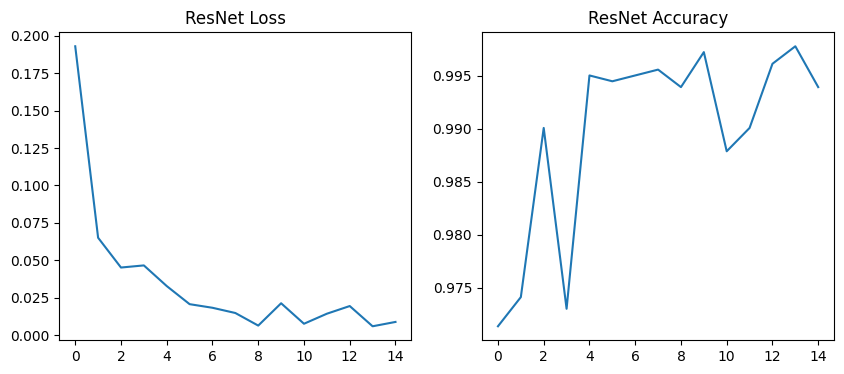


--- ResNet-50 Final Results ---
Accuracy:  0.9978
Precision: 0.9978
Recall:    0.9978
F1-Score:  0.9978
AUC Score: 1.0000


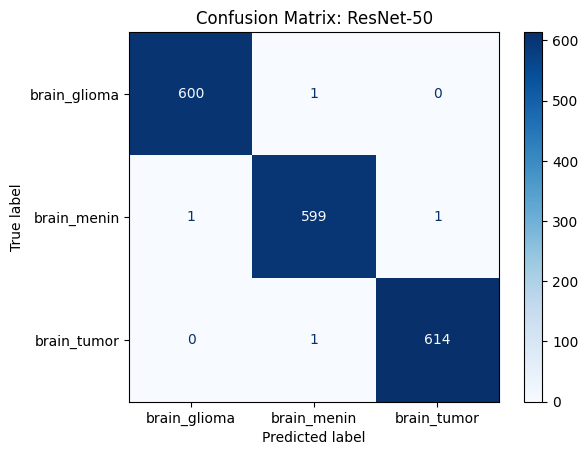

In [ ]:
print("ResNet-50")
model_res = models.resnet50(weights='IMAGENET1K_V1')
model_res.fc = nn.Linear(model_res.fc.in_features, NUM_CLASSES)
model_res = model_res.to(device)

optimizer = optim.Adam(model_res.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

history_res = {'train_loss': [], 'test_acc': []}
best_acc_res = 0.0

for epoch in range(15):
    model_res.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_res(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model_res.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_res(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_set)
    history_res['train_loss'].append(train_loss/len(train_loader))
    history_res['test_acc'].append(acc)

    if acc > best_acc_res:
        best_acc_res = acc
        torch.save(model_res.state_dict(), 'resnet50_best.pth')

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_res['train_loss']); plt.title('ResNet Loss')
plt.subplot(1, 2, 2); plt.plot(history_res['test_acc']); plt.title('ResNet Accuracy')
plt.show()

model_res.load_state_dict(torch.load('resnet50_best.pth'))
res_results = evaluate_model(model_res, test_loader, device, "ResNet-50")
del model_res, optimizer; torch.cuda.empty_cache()

**U-Net Encoder**

U-Net Encoder...
Epoch 1 | Loss: 0.9059 | Test Acc: 0.7061
Epoch 2 | Loss: 0.6853 | Test Acc: 0.7221
Epoch 3 | Loss: 0.6689 | Test Acc: 0.7287
Epoch 4 | Loss: 0.6530 | Test Acc: 0.7386
Epoch 5 | Loss: 0.6341 | Test Acc: 0.7358
Epoch 6 | Loss: 0.6453 | Test Acc: 0.7397
Epoch 7 | Loss: 0.6253 | Test Acc: 0.7039
Epoch 8 | Loss: 0.6341 | Test Acc: 0.7072
Epoch 9 | Loss: 0.6206 | Test Acc: 0.7501
Epoch 10 | Loss: 0.6175 | Test Acc: 0.7457
Epoch 11 | Loss: 0.6206 | Test Acc: 0.7111
Epoch 12 | Loss: 0.6188 | Test Acc: 0.7331
Epoch 13 | Loss: 0.6248 | Test Acc: 0.7380
Epoch 14 | Loss: 0.5974 | Test Acc: 0.7105
Epoch 15 | Loss: 0.6047 | Test Acc: 0.7485


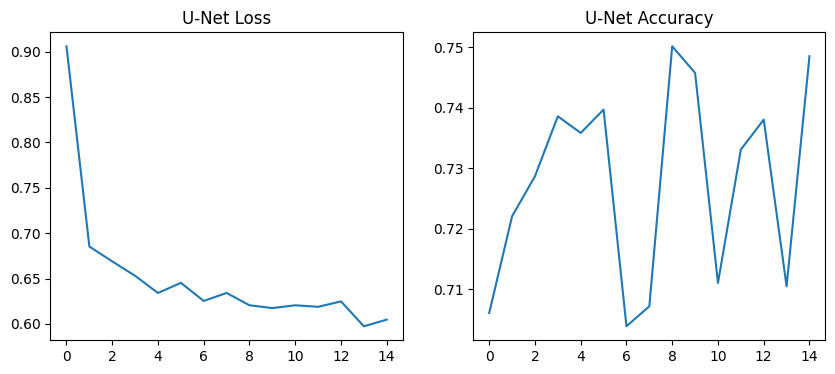


--- U-Net Encoder Final Results ---
Accuracy:  0.7501
Precision: 0.7535
Recall:    0.7493
F1-Score:  0.7479
AUC Score: 0.8981


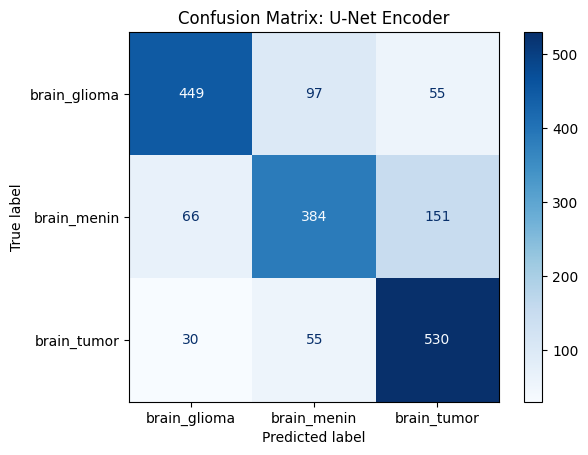

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(), nn.Conv2d(64, 64, 3, padding=1), nn.ReLU())
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.Conv2d(128, 128, 3, padding=1), nn.ReLU())
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.Conv2d(256, 256, 3, padding=1), nn.ReLU())
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, NUM_CLASSES)

    def forward(self, x):
        x = self.pool1(self.enc1(x))
        x = self.pool2(self.enc2(x))
        x = self.gap(self.enc3(x))
        return self.fc(x.view(x.size(0), -1))

print("U-Net Encoder...")
model_unet = UNetEncoder().to(device)
optimizer = optim.Adam(model_unet.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

history_unet = {'train_loss': [], 'test_acc': []}
best_acc_unet = 0.0

for epoch in range(15):
    model_unet.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_unet(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model_unet.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_unet(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_set)
    history_unet['train_loss'].append(train_loss/len(train_loader))
    history_unet['test_acc'].append(acc)

    if acc > best_acc_unet:
        best_acc_unet = acc
        torch.save(model_unet.state_dict(), 'unet_best.pth')

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_unet['train_loss']); plt.title('U-Net Loss')
plt.subplot(1, 2, 2); plt.plot(history_unet['test_acc']); plt.title('U-Net Accuracy')
plt.show()

model_unet.load_state_dict(torch.load('unet_best.pth'))
unet_results = evaluate_model(model_unet, test_loader, device, "U-Net Encoder")
del model_unet, optimizer; torch.cuda.empty_cache()

**Vision Transformer**

Initializing ViT-B-16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:07<00:00, 48.4MB/s]


Epoch 1 | Loss: 0.1964 | Test Acc: 0.9708
Epoch 2 | Loss: 0.0529 | Test Acc: 0.9719
Epoch 3 | Loss: 0.0524 | Test Acc: 0.9873
Epoch 4 | Loss: 0.0333 | Test Acc: 0.9912
Epoch 5 | Loss: 0.0230 | Test Acc: 0.9961
Epoch 6 | Loss: 0.0103 | Test Acc: 0.9972
Epoch 7 | Loss: 0.0188 | Test Acc: 0.9945
Epoch 8 | Loss: 0.0163 | Test Acc: 0.9917
Epoch 9 | Loss: 0.0131 | Test Acc: 0.9961
Epoch 10 | Loss: 0.0079 | Test Acc: 0.9967
Epoch 11 | Loss: 0.0104 | Test Acc: 0.9895
Epoch 12 | Loss: 0.0095 | Test Acc: 0.9945
Epoch 13 | Loss: 0.0200 | Test Acc: 0.9873
Epoch 14 | Loss: 0.0082 | Test Acc: 0.9895
Epoch 15 | Loss: 0.0083 | Test Acc: 0.9934


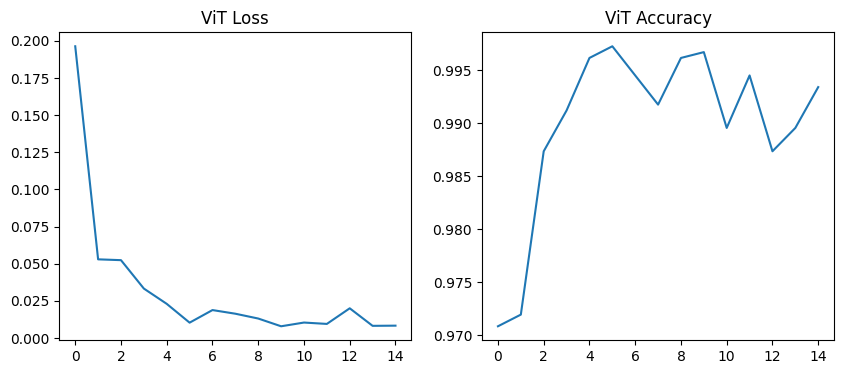


--- ViT-B-16 Final Results ---
Accuracy:  0.9972
Precision: 0.9972
Recall:    0.9973
F1-Score:  0.9973
AUC Score: 0.9999


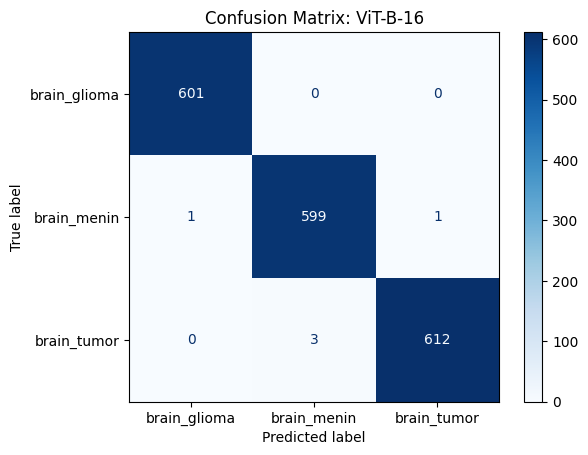

In [ ]:
print("Initializing ViT-B-16...")
model_vit = models.vit_b_16(weights='IMAGENET1K_V1')
model_vit.heads.head = nn.Linear(model_vit.heads.head.in_features, NUM_CLASSES)
model_vit = model_vit.to(device)

optimizer = optim.AdamW(model_vit.parameters(), lr=3e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

history_vit = {'train_loss': [], 'test_acc': []}
best_acc_vit = 0.0

for epoch in range(15):
    model_vit.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_vit(imgs), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model_vit.eval()
    correct = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model_vit(imgs).argmax(dim=1)
            correct += (preds == labels).sum().item()

    acc = correct / len(test_set)
    history_vit['train_loss'].append(train_loss/len(train_loader))
    history_vit['test_acc'].append(acc)

    if acc > best_acc_vit:
        best_acc_vit = acc
        torch.save(model_vit.state_dict(), 'vit_best.pth')

    print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.plot(history_vit['train_loss'],color='red'); plt.title('ViT Loss')
plt.subplot(1, 2, 2); plt.plot(history_vit['test_acc']); plt.title('ViT Accuracy')
plt.show()

model_vit.load_state_dict(torch.load('vit_best.pth'))
vit_results = evaluate_model(model_vit, test_loader, device, "ViT-B-16")
del model_vit, optimizer; torch.cuda.empty_cache()

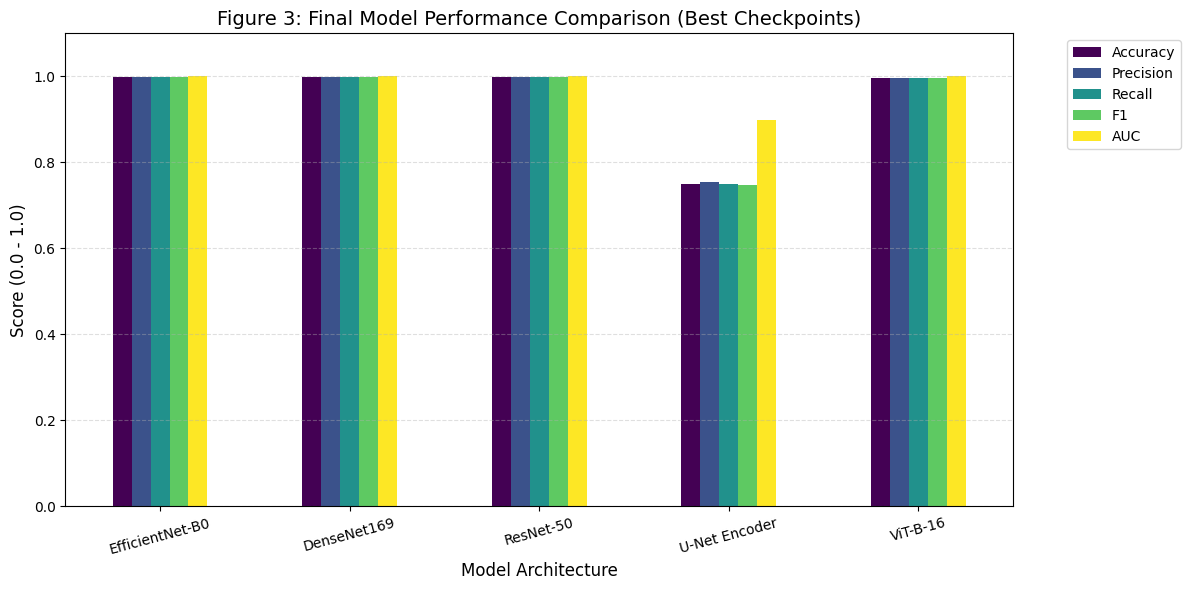

,Model,Accuracy,Precision,Recall,F1,AUC
0,EfficientNet-B0,0.999450,0.999446,0.999445,0.999445,1.000000
1,DenseNet169,0.998899,0.998903,0.998903,0.998903,0.999996
2,ResNet-50,0.997799,0.997794,0.997794,0.997794,0.999991
3,U-Net Encoder,0.750138,0.753460,0.749271,0.747887,0.898061
4,ViT-B-16,0.997248,0.997241,0.997265,0.997252,0.999917


In [ ]:
import pandas as pd

all_metrics = [b0_results, dense_results, res_results, unet_results, vit_results]
df_final = pd.DataFrame(all_metrics)

plt.figure(figsize=(12, 7), dpi=100)
ax = df_final.plot(x='Model', kind='bar', figsize=(12, 6), colormap='viridis', ax=plt.gca())
plt.title('Figure 3: Final Model Performance Comparison (Best Checkpoints)', fontsize=14)
plt.ylabel('Score (0.0 - 1.0)', fontsize=12)
plt.xlabel('Model Architecture', fontsize=12)
plt.ylim(0.0, 1.1)
plt.xticks(rotation=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to see bars clearly
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# Save this for Word
plt.savefig('final_comparison_results.png', bbox_inches='tight')
plt.show()

df_final

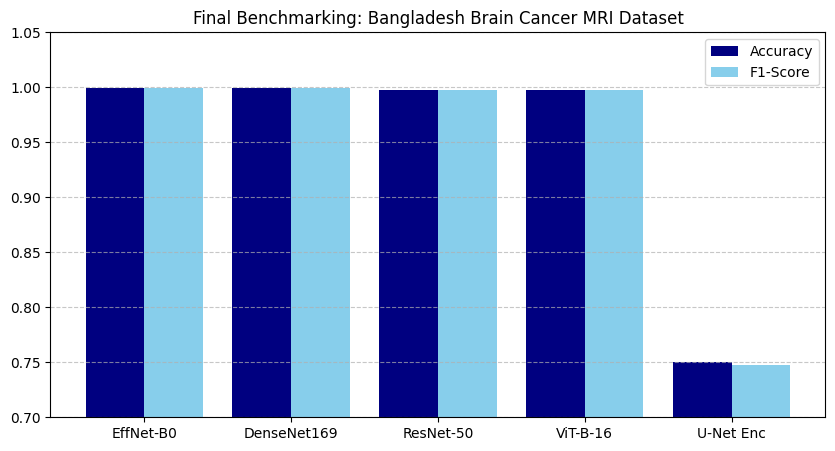

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

final_data = {
     'Model': ['EffNet-B0', 'DenseNet169', 'ResNet-50', 'ViT-B-16', 'U-Net Enc'],
    'Accuracy': [0.999450, 0.998899, 0.997799, 0.997248, 0.750138],
    'F1-Score': [0.999445, 0.998903, 0.997794, 0.997252, 0.747887]
}
df = pd.DataFrame(final_data)

plt.figure(figsize=(10, 5))
x = np.arange(len(df['Model']))
plt.bar(x - 0.2, df['Accuracy'], 0.4, label='Accuracy', color='navy')
plt.bar(x + 0.2, df['F1-Score'], 0.4, label='F1-Score', color='skyblue')

plt.xticks(x, df['Model'])
plt.ylim(0.7, 1.05)
plt.title('Final Benchmarking: Bangladesh Brain Cancer MRI Dataset')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Testing the Models / Or trying to use the model**

In [ ]:
from PIL import Image
import torch.nn.functional as F

def predict_brain_scan(img_path, models_dict, device):
    # 1. Load and Preprocess the image to match 224x224 input
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)

    print(f"--- Inference Results for {img_path} ---")

    # 2. Run inference through each model in your top_models dictionary
    for name, model in models_dict.items():
        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            probs = F.softmax(output, dim=1)
            confidence, pred = torch.max(probs, 1)

            # Map index to tumor class
            classes = ['Glioma', 'Meningioma', 'Tumor']
            print(f"{name}: {classes[pred.item()]} ({confidence.item()*100:.2f}%)")

predict_brain_scan('Tr-me_0010.jpg', top_models, device)


--- Inference Results for Tr-me_0010.jpg ---
EfficientNet-B0: Meningioma (77.43%)
DenseNet169: Meningioma (99.81%)
ResNet-50: Meningioma (99.99%)
